In [86]:
# Open terminal in your project folder
!git init
!git add .
!git commit -m "Initial commit: dataset and project setup"

Reinitialized existing Git repository in C:/Users/User/OneDrive/4ftc2113  25001700/CW3/.git/
[main c40d5cb] Initial commit: dataset and project setup
 6 files changed, 10000 insertions(+), 10000 deletions(-)


In [87]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [88]:
df = pd.read_csv('data.csv')
df.head()
df.describe()


,age,stress_level,sleep_hours,physical_activity_days,depression_score,anxiety_score,social_support_score,productivity_score
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000
mean,41.557600,5.572000,6.473000,3.505700,15.039900,10.56180,50.117700,77.312210
std,13.749581,2.887741,1.473944,2.282737,8.990839,6.32264,29.229278,14.061202
min,18.000000,1.000000,3.000000,0.000000,0.000000,0.00000,0.000000,42.800000
25%,30.000000,3.000000,5.500000,2.000000,7.000000,5.00000,25.000000,65.800000
50%,41.500000,6.000000,6.500000,4.000000,15.000000,11.00000,50.000000,77.600000
75%,53.000000,8.000000,7.500000,5.000000,23.000000,16.00000,76.000000,89.200000
max,65.000000,10.000000,10.000000,7.000000,30.000000,21.00000,100.000000,100.000000


In [89]:
print("Current columns:", df.columns.tolist())


Current columns: ['age', 'gender', 'employment_status', 'work_environment', 'mental_health_history', 'seeks_treatment', 'stress_level', 'sleep_hours', 'physical_activity_days', 'depression_score', 'anxiety_score', 'social_support_score', 'productivity_score', 'mental_health_risk']


In [90]:
df.isnull().sum()

age                       0
gender                    0
employment_status         0
work_environment          0
mental_health_history     0
seeks_treatment           0
stress_level              0
sleep_hours               0
physical_activity_days    0
depression_score          0
anxiety_score             0
social_support_score      0
productivity_score        0
mental_health_risk        0
dtype: int64

In [91]:
duplicates = df.duplicated().sum()
print(duplicates)

0


In [92]:
# In your code/report:
print("Data types:")
print(df.dtypes)

Data types:
age                         int64
gender                     object
employment_status          object
work_environment           object
mental_health_history      object
seeks_treatment            object
stress_level                int64
sleep_hours               float64
physical_activity_days      int64
depression_score            int64
anxiety_score               int64
social_support_score        int64
productivity_score        float64
mental_health_risk         object
dtype: object


In [93]:
print("Unique values per column:")
for col in df.columns:
    print(f"{col}: {df[col].nunique()} values")

Unique values per column:
age: 48 values
gender: 4 values
employment_status: 4 values
work_environment: 3 values
mental_health_history: 2 values
seeks_treatment: 2 values
stress_level: 10 values
sleep_hours: 71 values
physical_activity_days: 8 values
depression_score: 31 values
anxiety_score: 22 values
social_support_score: 101 values
productivity_score: 546 values
mental_health_risk: 3 values


In [94]:
print("Current gender values:")
print(df['gender'].value_counts())

Current gender values:
gender
Male                 4557
Female               4457
Non-binary            520
Prefer not to say     466
Name: count, dtype: int64


In [95]:
print(df['work_environment'].value_counts())
print(df['employment_status'].value_counts())
print(df['mental_health_history'].value_counts())
print(df['seeks_treatment'].value_counts())
print(df['mental_health_risk'].value_counts())


work_environment
On-site    5044
Remote     3009
Hybrid     1947
Name: count, dtype: int64
employment_status
Employed         5868
Student          2043
Self-employed    1045
Unemployed       1044
Name: count, dtype: int64
mental_health_history
No     6969
Yes    3031
Name: count, dtype: int64
seeks_treatment
No     6012
Yes    3988
Name: count, dtype: int64
mental_health_risk
Medium    5892
High      2369
Low       1739
Name: count, dtype: int64


In [96]:
categorical_cols = ['gender', 'work_environment', 'employment_status', 
                    'mental_health_history', 'mental_health_risk']

df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

In [97]:
# Example 1: Create mental health composite score
df['mental_health_composite'] = (
    df['depression_score'] + df['anxiety_score'] - df['social_support_score']
)

# Example 2: Categorize stress levels
df['stress_category'] = pd.cut(
    df['stress_level'], 
    bins=[0, 3, 7, 10],
    labels=['Low', 'Medium', 'High']
)
# Example 3: Calculate sleep efficiency ratio
df['sleep_activity_ratio'] = df['sleep_hours'] / (df['physical_activity_days'] + 1)

In [98]:
# Identify outliers using IQR
Q1 = df[['stress_level', 'depression_score']].quantile(0.25)
Q3 = df[['stress_level', 'depression_score']].quantile(0.75)
IQR = Q3 - Q1

# Decide: Cap, remove, or keep with explanation
# Option: Cap outliers
df['stress_level_capped'] = np.where(
    df['stress_level'] > (Q3['stress_level'] + 1.5 * IQR['stress_level']),
    Q3['stress_level'] + 1.5 * IQR['stress_level'],
    df['stress_level']
)

In [99]:
# One-hot encode stress_category (you created it)
df = pd.get_dummies(df, columns=['stress_category'], drop_first=True)

In [100]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['seeks_treatment_encoded'] = le.fit_transform(df['seeks_treatment'])

In [101]:
X = df.drop(['seeks_treatment', 'seeks_treatment_encoded'], axis=1)
y = df['seeks_treatment_encoded']
print(f"Final feature shape: {X.shape}")
print(f"Target distribution: {y.value_counts(normalize=True)}")

Final feature shape: (10000, 24)
Target distribution: seeks_treatment_encoded
0    0.6012
1    0.3988
Name: proportion, dtype: float64


In [102]:
df.head()

,age,seeks_treatment,stress_level,sleep_hours,physical_activity_days,depression_score,anxiety_score,social_support_score,productivity_score,gender_Male,...,employment_status_Unemployed,mental_health_history_Yes,mental_health_risk_Low,mental_health_risk_Medium,mental_health_composite,sleep_activity_ratio,stress_level_capped,stress_category_Medium,stress_category_High,seeks_treatment_encoded
0,56,Yes,6,6.2,3,28,17,54,59.7,True,...,False,True,False,False,-9,1.550000,6.0,True,False,1
1,46,Yes,10,9.0,4,30,11,85,54.9,False,...,False,False,False,False,-44,1.800000,10.0,False,True,1
2,32,No,7,7.7,2,24,7,62,61.3,False,...,False,True,False,True,-31,2.566667,7.0,True,False,0
3,60,No,4,4.5,4,6,0,95,97.0,False,...,False,False,True,False,-89,0.900000,4.0,True,False,0
4,25,Yes,3,5.4,0,24,12,70,69.0,False,...,False,True,False,False,-34,5.400000,3.0,False,False,1


In [103]:
df.to_csv('data_preprocessed.csv', index=False)

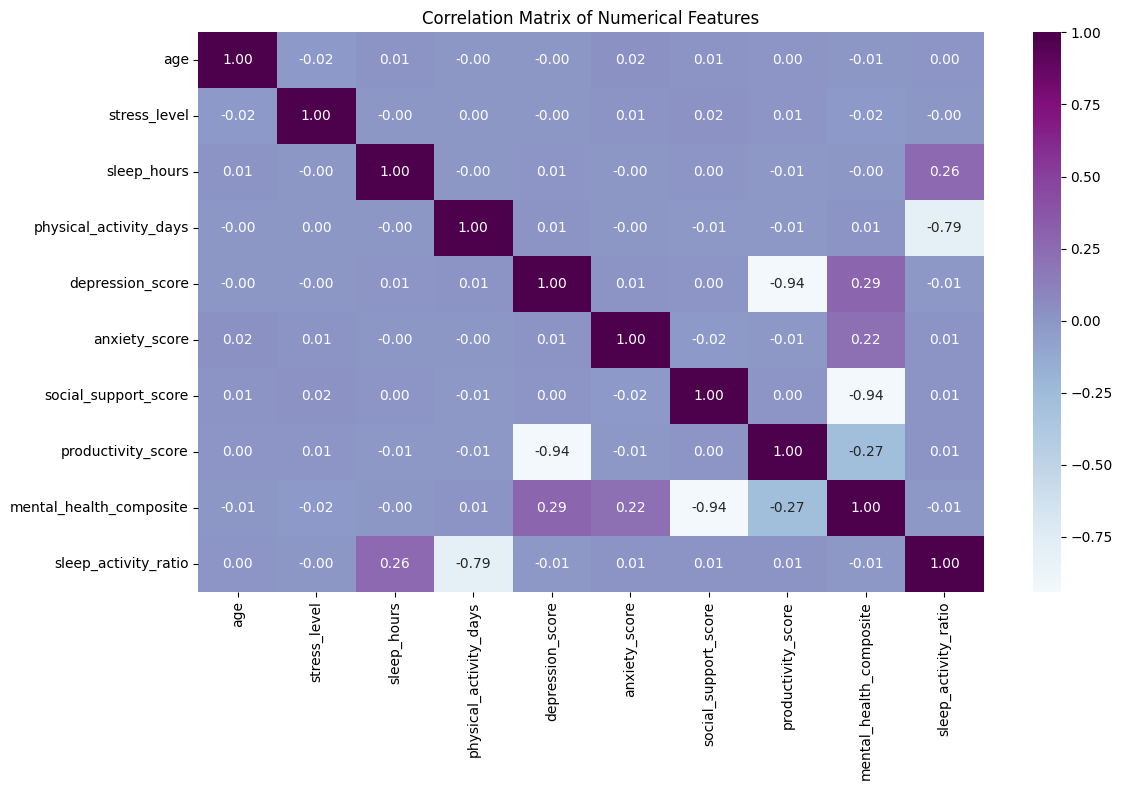

\nTop correlations with seeks_treatment:
seeks_treatment_encoded    1.000000
anxiety_score              0.010903
age                        0.009422
stress_level               0.008780
mental_health_composite    0.007774
physical_activity_days     0.006686
social_support_score       0.005215
depression_score           0.002473
sleep_activity_ratio       0.002184
sleep_hours                0.001853
Name: seeks_treatment_encoded, dtype: float64


In [104]:


# Select numerical columns for correlation
numerical_cols = ['age', 'stress_level', 'sleep_hours', 'physical_activity_days',
                  'depression_score', 'anxiety_score', 'social_support_score',
                  'productivity_score', 'mental_health_composite', 'sleep_activity_ratio']

corr_matrix = df[numerical_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='BuPu', center=0, fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=300)
plt.show()

# Identify top correlations with target
target_corr = df[numerical_cols + ['seeks_treatment_encoded']].corr()['seeks_treatment_encoded'].abs().sort_values(ascending=False)
print("\\nTop correlations with seeks_treatment:")
print(target_corr.head(10))

In [105]:
 #2. T-test for Treatment Seekers vs Non-Seekers

from scipy import stats

# Compare means between groups
group_yes = df[df['seeks_treatment'] == 'Yes']
group_no = df[df['seeks_treatment'] == 'No']

print("=== T-TEST RESULTS: Treatment Seekers vs Non-Seekers ===\\n")

for col in ['depression_score', 'anxiety_score', 'stress_level', 'social_support_score']:
    t_stat, p_val = stats.ttest_ind(group_yes[col], group_no[col])
    print(f"{col}:")
    print(f"  Treatment Yes (n={len(group_yes)}): Mean = {group_yes[col].mean():.2f}")
    print(f"  Treatment No  (n={len(group_no)}): Mean = {group_no[col].mean():.2f}")
    print(f"  t-statistic = {t_stat:.3f}, p-value = {p_val:.4f}")
    print(f"  Interpretation: {'Significant difference' if p_val < 0.05 else 'No significant difference'}\\n")

=== T-TEST RESULTS: Treatment Seekers vs Non-Seekers ===\n
depression_score:
  Treatment Yes (n=3988): Mean = 15.07
  Treatment No  (n=6012): Mean = 15.02
  t-statistic = 0.247, p-value = 0.8047
  Interpretation: No significant difference\n
anxiety_score:
  Treatment Yes (n=3988): Mean = 10.65
  Treatment No  (n=6012): Mean = 10.51
  t-statistic = 1.090, p-value = 0.2756
  Interpretation: No significant difference\n
stress_level:
  Treatment Yes (n=3988): Mean = 5.54
  Treatment No  (n=6012): Mean = 5.59
  t-statistic = -0.878, p-value = 0.3800
  Interpretation: No significant difference\n
social_support_score:
  Treatment Yes (n=3988): Mean = 49.93
  Treatment No  (n=6012): Mean = 50.24
  t-statistic = -0.521, p-value = 0.6020
  Interpretation: No significant difference\n


C:\Users\User\AppData\Local\Temp\ipykernel_10184\1275485011.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='seeks_treatment', y='depression_score', data=df, palette=['skyblue', 'salmon'])


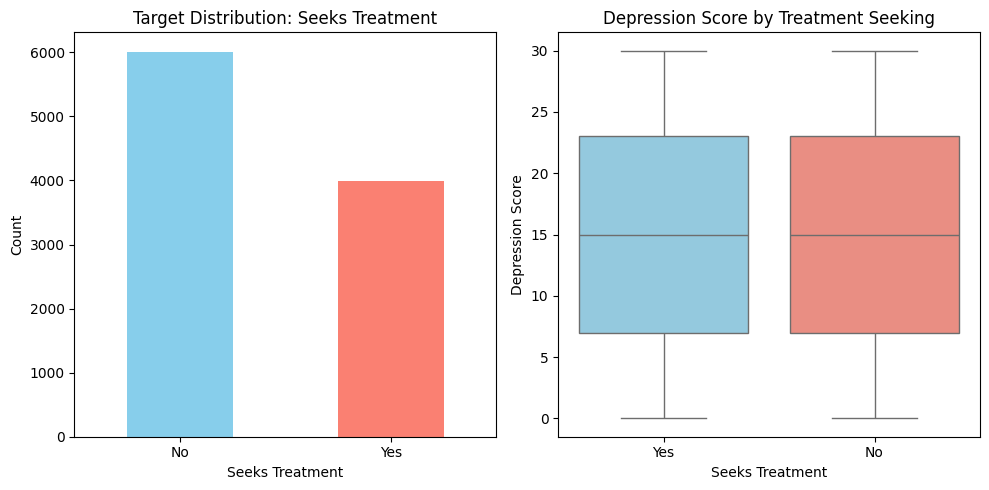

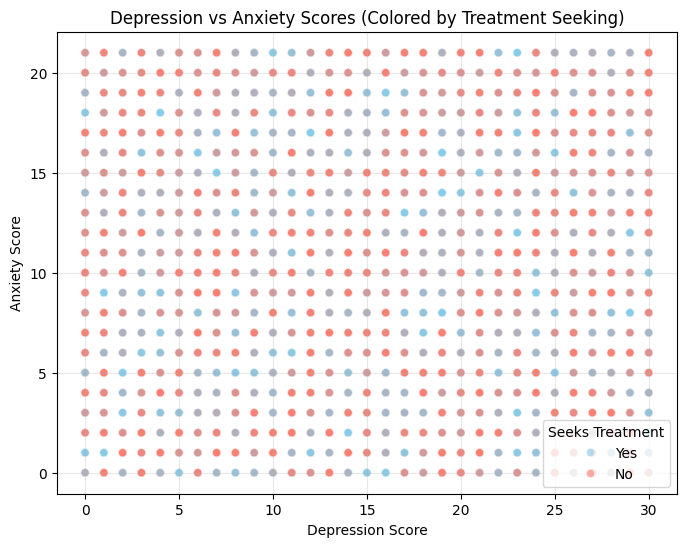

In [106]:
# A) Distribution of target
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
df['seeks_treatment'].value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Target Distribution: Seeks Treatment')
plt.xlabel('Seeks Treatment')
plt.ylabel('Count')
plt.xticks(rotation=0)

# B) Boxplot: Depression score by treatment
plt.subplot(1, 2, 2)
sns.boxplot(x='seeks_treatment', y='depression_score', data=df, palette=['skyblue', 'salmon'])
plt.title('Depression Score by Treatment Seeking')
plt.xlabel('Seeks Treatment')
plt.ylabel('Depression Score')

plt.tight_layout()
plt.savefig('target_analysis.png', dpi=300)
plt.show()

# C) Scatter: Depression vs Anxiety colored by treatment
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='depression_score', y='anxiety_score', 
                hue='seeks_treatment', alpha=0.6, palette=['skyblue', 'salmon'])
plt.title('Depression vs Anxiety Scores (Colored by Treatment Seeking)')
plt.xlabel('Depression Score')
plt.ylabel('Anxiety Score')
plt.legend(title='Seeks Treatment')
plt.grid(True, alpha=0.3)
plt.savefig('depression_anxiety_scatter.png', dpi=300)
plt.show()

In [107]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Assuming df is your DataFrame
# Convert target to numeric
df['seeks_treatment'] = df['seeks_treatment'].map({'Yes': 1, 'No': 0})

# Final split
X = df.drop(columns=['seeks_treatment'])
y = df['seeks_treatment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale numerical features only
numerical_cols = ['age', 'stress_level', 'sleep_hours', 'physical_activity_days',
                  'depression_score', 'anxiety_score', 'social_support_score',
                  'productivity_score', 'mental_health_composite', 'sleep_activity_ratio',
                  'stress_level_capped']

scaler = StandardScaler()
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"Target balance: {np.mean(y_train):.3f} positive")

Training set: (8000, 25)
Test set: (2000, 25)
Target balance: 0.399 positive


In [108]:

from sklearn.linear_model import LogisticRegression

model = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
model.fit(X_train, y_train)

# Quick evaluation
from sklearn.metrics import accuracy_score
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.4f}")
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Full evaluation
y_pred_prob = model.predict_proba(X_test)[:, 1]

print("=== MODEL EVALUATION ===")
print(f"Accuracy: {accuracy:.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_prob):.4f}")
print("\\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\\nClassification Report:")
print(classification_report(y_test, y_pred))

# Get coefficients
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': model.coef_[0]
})
feature_importance['Abs_Importance'] = np.abs(feature_importance['Coefficient'])
feature_importance = feature_importance.sort_values('Abs_Importance', ascending=False)

print("\\n=== TOP 10 MOST IMPORTANT FEATURES ===")
for idx, row in feature_importance.head(10).iterrows():
    direction = "INCREASES" if row['Coefficient'] > 0 else "DECREASES"
    print(f"{row['Feature']:30} → {direction} treatment seeking (coef: {row['Coefficient']:.4f})")



Model Accuracy: 1.0000
=== MODEL EVALUATION ===
Accuracy: 1.0000
ROC-AUC: 1.0000
\nConfusion Matrix:
[[1202    0]
 [   0  798]]
\nClassification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1202
           1       1.00      1.00      1.00       798

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000

\n=== TOP 10 MOST IMPORTANT FEATURES ===
seeks_treatment_encoded        → INCREASES treatment seeking (coef: 11.6427)
mental_health_risk_Medium      → DECREASES treatment seeking (coef: -0.1081)
mental_health_history_Yes      → DECREASES treatment seeking (coef: -0.1037)
work_environment_Remote        → INCREASES treatment seeking (coef: 0.0949)
stress_category_High           → DECREASES treatment seeking (coef: -0.0829)
stress_category_Medium         → DECREASES treatment seeking (coef: -0.0639)
work_environment_O

In [109]:
from sklearn.model_selection import cross_val_score, GridSearchCV

# Cross-validation
cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
print(f"Cross-validation Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f})")

# Hyperparameter tuning (optional but good for marks)
param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l2', None],
    'solver': ['lbfgs', 'liblinear']
}

grid = GridSearchCV(LogisticRegression(max_iter=1000, random_state=42),
                    param_grid, cv=5, scoring='accuracy')
grid.fit(X_train, y_train)
print(f"Best params: {grid.best_params_}")
print(f"Best CV accuracy: {grid.best_score_:.4f}")

Cross-validation Accuracy: 1.0000 (+/- 0.0000)


c:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1232: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
c:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1232: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
c:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1232: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
c:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1232: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
c:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1232: UserWarning: Setting penalty=None will ignore the C and l1_ratio par

Best params: {'C': 0.01, 'penalty': 'l2', 'solver': 'lbfgs'}
Best CV accuracy: 1.0000


c:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
20 fits failed out of a total of 80.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
20 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\User\AppData\Lo

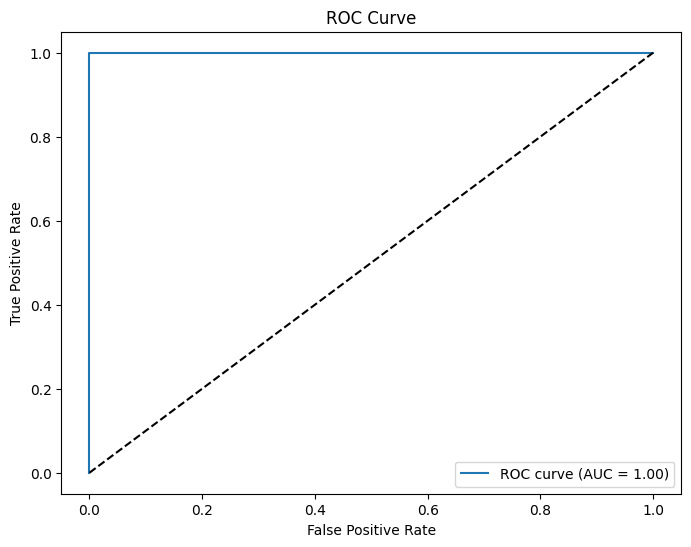

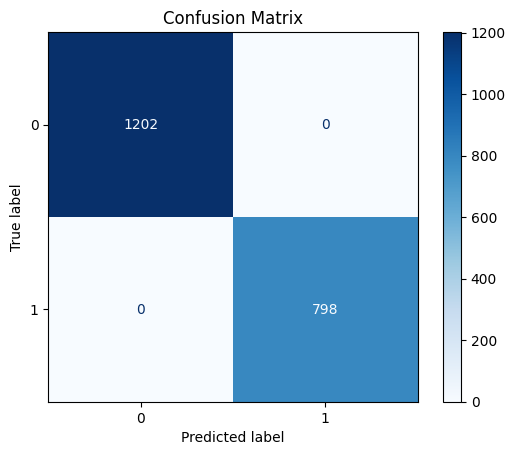

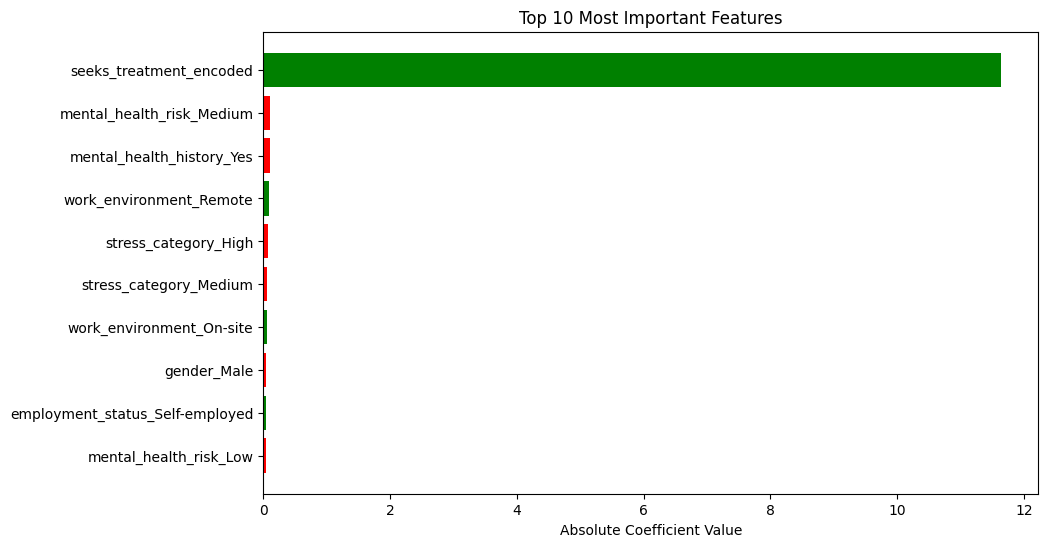

In [110]:

from sklearn.metrics import roc_curve, ConfusionMatrixDisplay

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc_score(y_test, y_pred_prob):.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.savefig('roc_curve.png', dpi=300)
plt.show()

# Confusion Matrix Heatmap
ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, cmap='Blues')
plt.title('Confusion Matrix')
plt.savefig('confusion_matrix.png', dpi=300)
plt.show()

# Feature Importance Plot
top_features = feature_importance.head(10)
plt.figure(figsize=(10, 6))
colors = ['green' if coef > 0 else 'red' for coef in top_features['Coefficient']]
plt.barh(top_features['Feature'], top_features['Abs_Importance'], color=colors)
plt.xlabel('Absolute Coefficient Value')
plt.title('Top 10 Most Important Features')
plt.gca().invert_yaxis()
plt.savefig('feature_importance.png', dpi=300)

plt.show()
